# Read shapefile

## Example 1: NYS county subdivision boundaries

In [11]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

gdf = gpd.read_file("./data/tl_2016_36_cousub/tl_2016_36_cousub.shp")

gdf.head()



,STATEFP,COUNTYFP,COUSUBFP,COUSUBNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CNECTAFP,NECTAFP,NCTADVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,36,017,55959,00979335,3601755959,Oxford,Oxford town,43,T1,G4040,None,None,None,A,155563470,911062,+42.3970735,-075.5962276,"POLYGON ((-75.67459 42.38286, -75.67432 42.382..."
1,36,017,57507,00979360,3601757507,Pharsalia,Pharsalia town,43,T1,G4040,None,None,None,A,100533128,774336,+42.5976196,-075.7338789,"POLYGON ((-75.79645 42.63828, -75.79172 42.638..."
2,36,017,58288,00979370,3601758288,Pitcher,Pitcher town,43,T1,G4040,None,None,None,A,73723336,37391,+42.5875820,-075.8279559,"POLYGON ((-75.88232 42.6377, -75.88167 42.6377..."
3,36,017,59817,00979398,3601759817,Preston,Preston town,43,T1,G4040,None,None,None,A,90327313,443458,+42.5033261,-075.6103565,"POLYGON ((-75.67005 42.55087, -75.66985 42.550..."
4,36,017,66894,00979490,3601766894,Sherburne,Sherburne town,43,T1,G4040,None,None,None,A,112803620,51669,+42.6939737,-075.4812144,"POLYGON ((-75.55251 42.7394, -75.55138 42.7394..."


In [12]:
gdf.shape

(1023, 19)

In [13]:
gdf.crs

<Geographic 2D CRS: EPSG:4269>
Name: NAD83
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: North America - onshore and offshore: Canada - Alberta; British Columbia; Manitoba; New Brunswick; Newfoundland and Labrador; Northwest Territories; Nova Scotia; Nunavut; Ontario; Prince Edward Island; Quebec; Saskatchewan; Yukon. Puerto Rico. United States (USA) - Alabama; Alaska; Arizona; Arkansas; California; Colorado; Connecticut; Delaware; Florida; Georgia; Hawaii; Idaho; Illinois; Indiana; Iowa; Kansas; Kentucky; Louisiana; Maine; Maryland; Massachusetts; Michigan; Minnesota; Mississippi; Missouri; Montana; Nebraska; Nevada; New Hampshire; New Jersey; New Mexico; New York; North Carolina; North Dakota; Ohio; Oklahoma; Oregon; Pennsylvania; Rhode Island; South Carolina; South Dakota; Tennessee; Texas; Utah; Vermont; Virginia; Washington; West Virginia; Wisconsin; Wyoming. US Virgin Islands. British Virgin Islands

In [14]:
gdf.columns

Index(['STATEFP', 'COUNTYFP', 'COUSUBFP', 'COUSUBNS', 'GEOID', 'NAME',
       'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'CNECTAFP', 'NECTAFP',
       'NCTADVFP', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON',
       'geometry'],
      dtype='object')

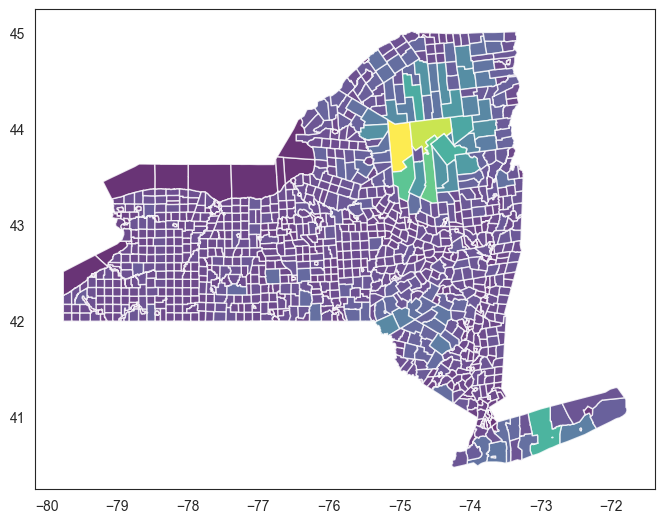

In [19]:

sns.set_style("white")
ax=gdf.plot(column="ALAND", cmap='viridis', figsize=(8,8), alpha=0.8)

# plt.axis('off')

<Axes: >

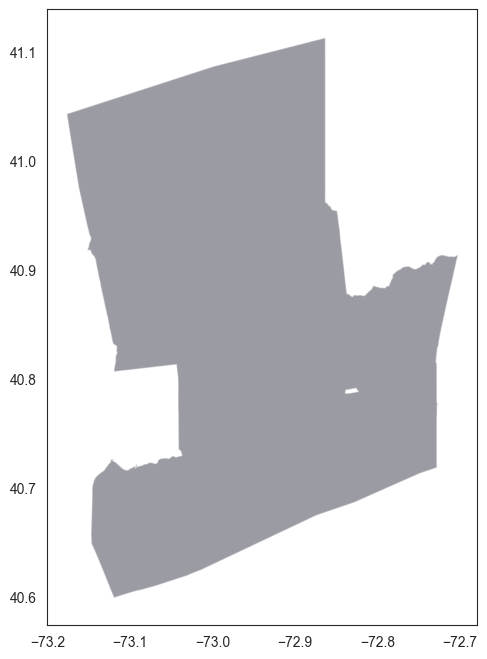

In [20]:
# Plot Brookhaven Town

gdf[gdf['NAME'].str.contains("Brookhaven")].plot(column="ALAND", figsize=(8,8), alpha=0.4)


## Exmaple 2: Chicago population

In [21]:
import geopandas as gpd
import geodatasets
import seaborn as sns
import matplotlib.pyplot as plt

chicago = gpd.read_file(geodatasets.get_path("geoda.chicago_commpop"))

chicago.head()

,community,NID,POP2010,POP2000,POPCH,POPPERCH,popplus,popneg,geometry
0,DOUGLAS,35,18238,26470,-8232,-31.099358,0,1,"MULTIPOLYGON (((-87.60914 41.84469, -87.60915 ..."
1,OAKLAND,36,5918,6110,-192,-3.142390,0,1,"MULTIPOLYGON (((-87.59215 41.81693, -87.59231 ..."
2,FULLER PARK,37,2876,3420,-544,-15.906433,0,1,"MULTIPOLYGON (((-87.6288 41.80189, -87.62879 4..."
3,GRAND BOULEVARD,38,21929,28006,-6077,-21.698922,0,1,"MULTIPOLYGON (((-87.60671 41.81681, -87.6067 4..."
4,KENWOOD,39,17841,18363,-522,-2.842673,0,1,"MULTIPOLYGON (((-87.59215 41.81693, -87.59215 ..."


<Axes: >

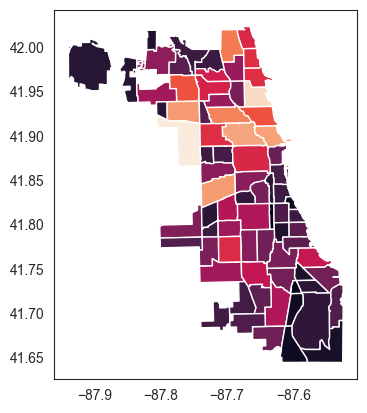

In [22]:
sns.set_style("white")
chicago.plot(column="POP2010")

# Read geojson

In [24]:
import geopandas as gpd
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx

nyc = gpd.read_file("./data/nyc.geojson")
nyc.head()

,OBJECTID,CTLabel,BoroCode,BoroName,CT2020,BoroCT2020,CDEligibil,NTAName,NTA2020,CDTA2020,CDTANAME,GEOID,PUMA,Shape__Area,Shape__Length,geometry
0,1,1,1,Manhattan,000100,1000100,I,The Battery-Governors Island-Ellis Island-Libe...,MN0191,MN01,MN01 Financial District-Tribeca (CD 1 Equivalent),36061000100,4121,1.843005e+06,10833.043929,"MULTIPOLYGON (((-74.04388 40.6902, -74.04351 4..."
1,2,22.01,1,Manhattan,002201,1002201,E,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061002201,4103,1.740174e+06,5779.062607,"POLYGON ((-73.97875 40.71994, -73.97879 40.719..."
2,3,26.02,1,Manhattan,002602,1002602,E,East Village,MN0303,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061002602,4103,1.114857e+06,4491.203220,"POLYGON ((-73.97559 40.72429, -73.97593 40.723..."
3,4,28,1,Manhattan,002800,1002800,E,East Village,MN0303,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061002800,4103,1.973679e+06,5627.555089,"POLYGON ((-73.9733 40.72744, -73.9738 40.72676..."
4,5,34,1,Manhattan,003400,1003400,I,East Village,MN0303,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061003400,4103,1.718452e+06,5503.307044,"POLYGON ((-73.97803 40.72944, -73.97806 40.729..."


In [25]:
nyc.shape

(2000, 16)

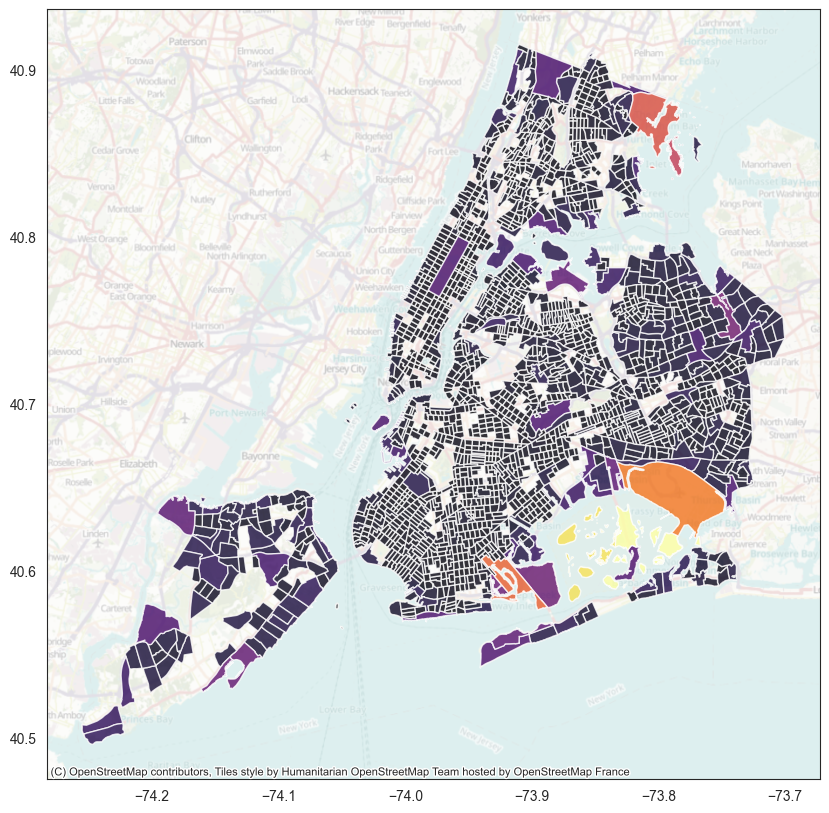

In [29]:
ax=nyc.plot(column='Shape__Length', figsize=(10,10), alpha=0.8, cmap='inferno')
cx.add_basemap(ax, crs=nyc.crs, alpha=0.3)

In [30]:
nyc.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [31]:
nyc_new = nyc.to_crs(epsg=3857)

In [33]:
nyc_new.head()

,OBJECTID,CTLabel,BoroCode,BoroName,CT2020,BoroCT2020,CDEligibil,NTAName,NTA2020,CDTA2020,CDTANAME,GEOID,PUMA,Shape__Area,Shape__Length,geometry
0,1,1,1,Manhattan,000100,1000100,I,The Battery-Governors Island-Ellis Island-Libe...,MN0191,MN01,MN01 Financial District-Tribeca (CD 1 Equivalent),36061000100,4121,1.843005e+06,10833.043929,"MULTIPOLYGON (((-8242526.915 4966752.47, -8242..."
1,2,22.01,1,Manhattan,002201,1002201,E,Lower East Side,MN0302,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061002201,4103,1.740174e+06,5779.062607,"POLYGON ((-8235277.201 4971120.516, -8235281.1..."
2,3,26.02,1,Manhattan,002602,1002602,E,East Village,MN0303,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061002602,4103,1.114857e+06,4491.203220,"POLYGON ((-8234925.529 4971759.429, -8234962.8..."
3,4,28,1,Manhattan,002800,1002800,E,East Village,MN0303,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061002800,4103,1.973679e+06,5627.555089,"POLYGON ((-8234670.022 4972221.323, -8234725.8..."
4,5,34,1,Manhattan,003400,1003400,I,East Village,MN0303,MN03,MN03 Lower East Side-Chinatown (CD 3 Equivalent),36061003400,4103,1.718452e+06,5503.307044,"POLYGON ((-8235196.454 4972515.857, -8235199.6..."
